  0%|          | 0/5 [00:00<?, ?it/s]

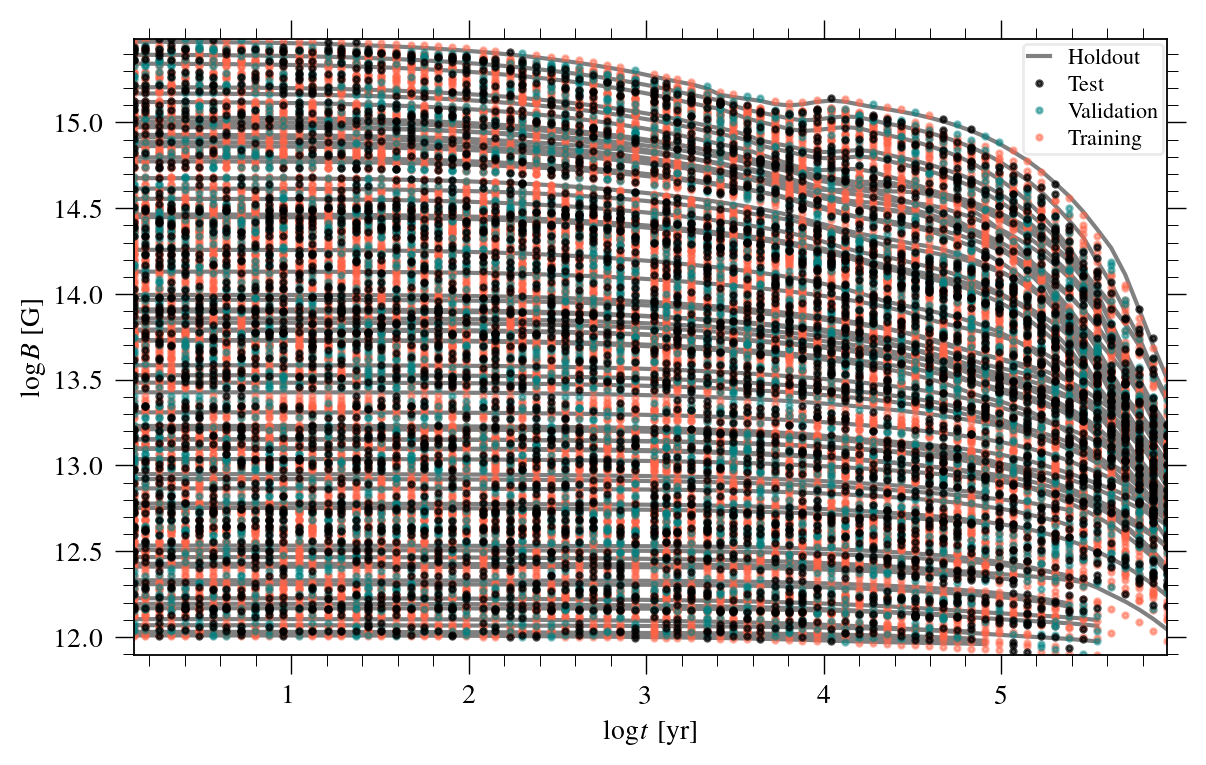

In [13]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm


plt.style.use('./astrostyle.mplstyle')


DATASET_TYPES = ["train", "valid", "test", "holdout"]
DATASET_COLORS = ["tomato", "teal", "black", "gray"]
DATASET_LABELS = ["Training", "Validation", "Test", "Holdout"]
ZORDER_BY_TYPE = {"train": 1, "valid": 2, "test": 3, "holdout": 0}
LABEL_BY_COL = {
    "logt": "$\log t$ [yr]",
    "logB": "$\log B$ [G]",
    "env=H": "Heavy envelope",
    "env=L": "Light envelope",
    "logB": "$\log B$ [G]",
    "logB0": "$\log B_0$ [G]",
    "logt": "$\log t$ [yr]",
    "logP": "$\log P$ [s]",
    "logPdot": "$\log \dot{P}$ [s/s]",
    "M": "$M$ [$M_\odot$]",
    "logL": "$\log L$ [$10^{33}\,$ erg/s]",
    }

COLOR_BY_TYPE = {typ: col for typ, col in zip(DATASET_TYPES, DATASET_COLORS)}
LABEL_BY_TYPE = {typ: lbl for typ, lbl in zip(DATASET_TYPES, DATASET_LABELS)}
ALPHA_BY_TYPE = {"train": 0.5, "valid": 0.5, "test": 0.7, "holdout":1}


def read_datasets(folder):
    filepaths = glob.glob(os.path.join(folder, "**", "*.csv*"), recursive=True)
    data = {}
    for filepath in tqdm(filepaths):
        for key in DATASET_TYPES:
            if key in filepath:
                assert key not in data
                data[key] = pd.read_csv(filepath, index_col="index")
    return data


def make_dataset_plot(savepath=None):
    x_col = "logt"
    y_col = "logB"

    # get the figure size from the style and double it for better visibility
    style_figsize = plt.rcParams['figure.figsize']
    plt.figure(figsize=(style_figsize[0] * 2, style_figsize[1] * 2))
    for key, dataset in data.items():
        color = COLOR_BY_TYPE[key]
        label = LABEL_BY_TYPE[key]
        alpha = ALPHA_BY_TYPE[key]
        zorder = ZORDER_BY_TYPE[key]

        if key == "holdout":
            plt.plot([], [], "-", color=color, alpha=alpha, label=label)
            indices = set(dataset.index)
            for index in indices:
                system = dataset.loc[index]
                plt.plot(system[x_col], system[y_col], "-", color=color, alpha=alpha, zorder=zorder)
        else:
            plt.plot(dataset[x_col], dataset[y_col], "o", mfc=color, markersize=2, color=color, alpha=alpha, zorder=zorder, label=label)
    plt.xlabel("$\log t$ [yr]")
    plt.ylabel("$\log B$ [G]")
    plt.legend()
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight")
    plt.show()


data = read_datasets("../../data/datasets")
make_dataset_plot(savepath="../../figures/datasets_plot.pdf")

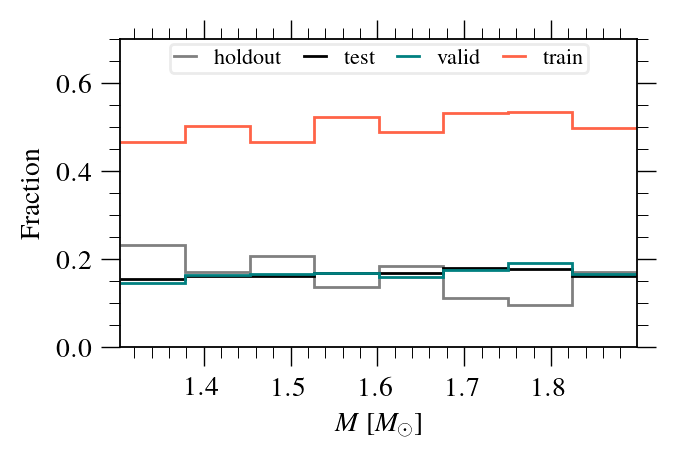

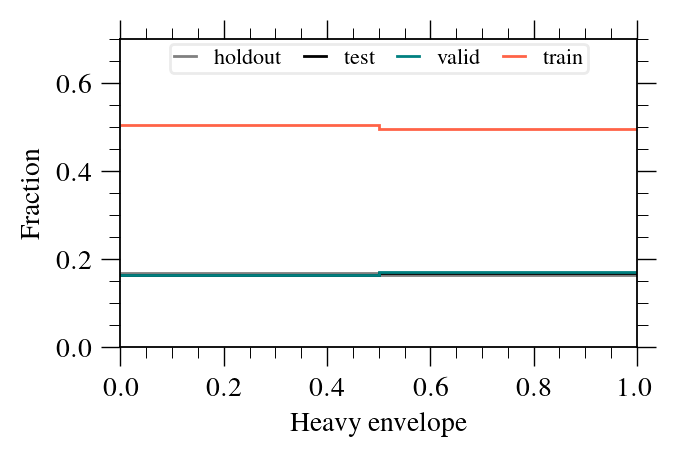

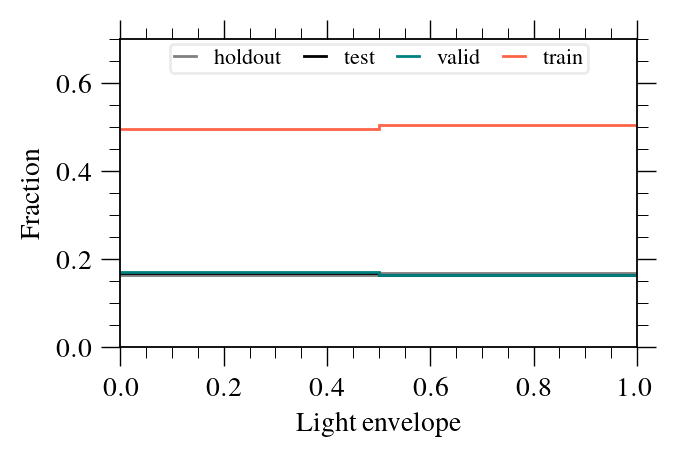

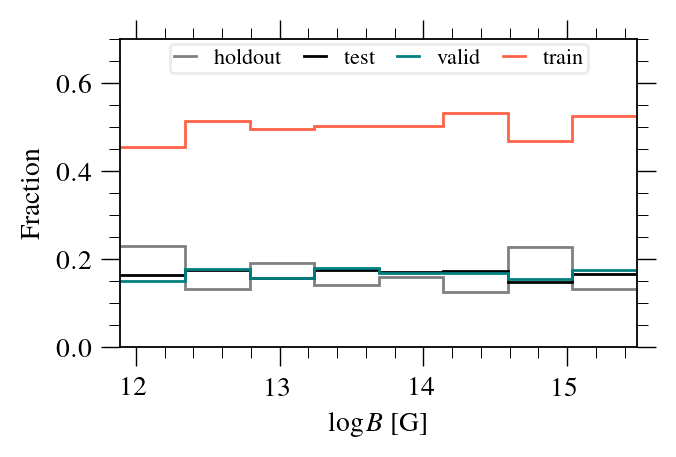

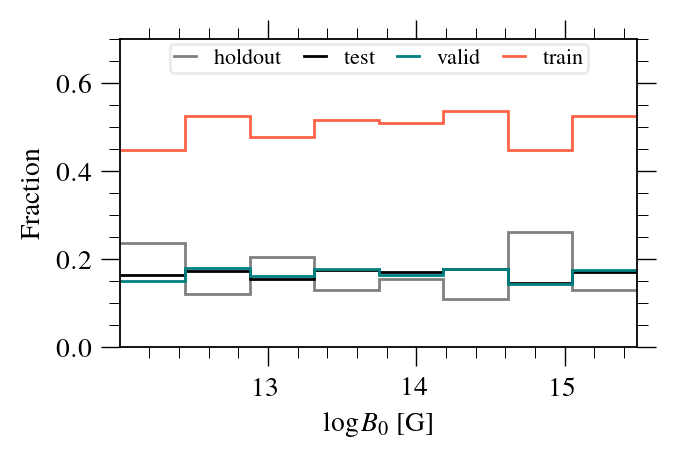

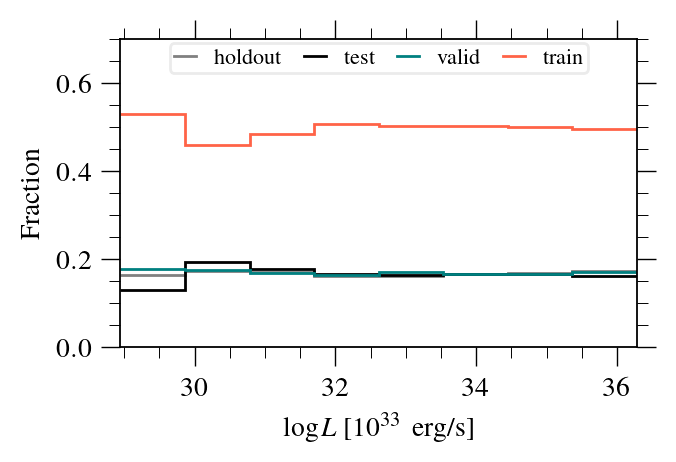

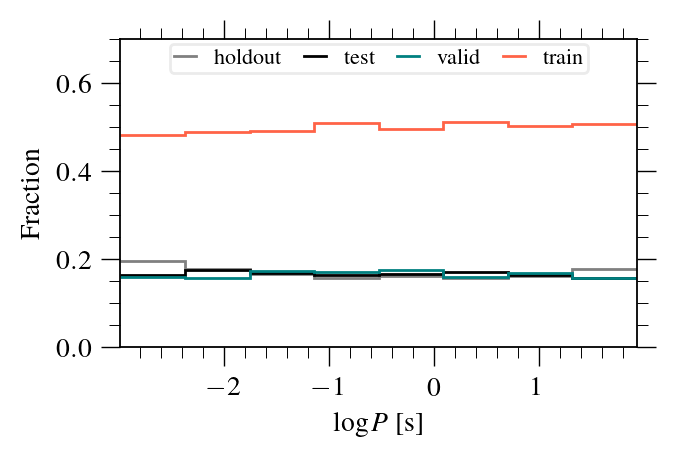

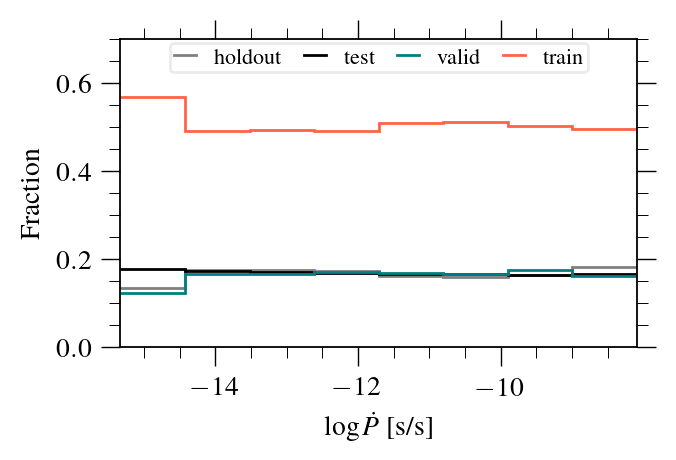

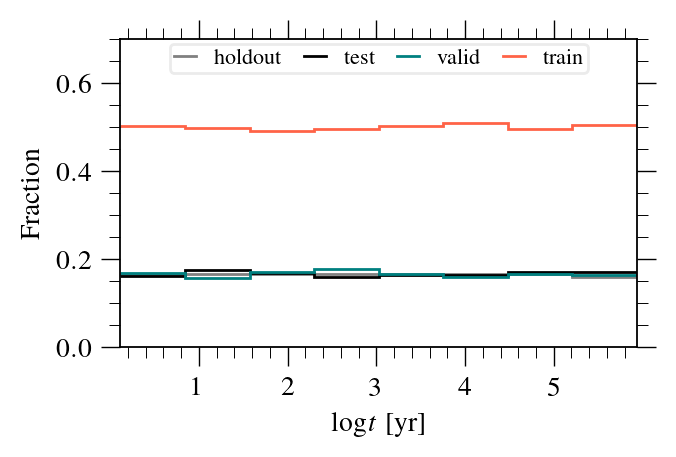

In [15]:
# Plot distributions
columns_to_plot = list(sorted(set(data["train"].columns)))# - set(["logt_yr", "envelope"])))

for xcol in columns_to_plot:
    x_data = {key: dataset[xcol] for key, dataset in data.items()}
    n_total = sum([len(value) for value in x_data.values()])
    n_unique = len(set().union(*x_data.values()))

    xmin = min([min(x_data_column) for x_data_column in x_data.values()])
    xmax = max([max(x_data_column) for x_data_column in x_data.values()])
    assert xmin != xmax

    n_bins = min(n_unique, 8)
    in_log = (n_bins > 2) and (xmin > 0) and (abs(xmax) / abs(xmin) > 100)

    if n_bins > 2:
        if in_log:
            bins = np.exp(np.linspace(np.log(xmin), np.log(xmax), n_bins+1))
        else:
            bins = np.linspace(xmin, xmax, n_bins+1)
    else:
        bins = n_bins

    counts_by_dataset = {}
    common_edges = None
    total_counts = None
    for key, values in x_data.items():
        counts, edges = np.histogram(values, bins=bins)
        if common_edges is None:
            assert total_counts is None
            common_edges = edges
            total_counts = counts.copy()
        else:
            assert total_counts is not None
            assert np.all(common_edges == edges)
            total_counts += counts
        counts_by_dataset[key] = counts

    ls = "--" if key == "holdout" else "-"

    plt.figure()
    for key, counts in counts_by_dataset.items():
        plt.stairs(counts / total_counts, edges=common_edges, color=COLOR_BY_TYPE[key], label=key, baseline=None, ls=ls)
    plt.ylim(ymin=0, ymax=0.7)
    plt.xscale("log" if in_log else "linear")
    plt.legend(loc="upper center", ncol=4)
    plt.xlabel(LABEL_BY_COL[xcol])
    plt.ylabel("Fraction")
    plt.savefig(f"../../figures/distribution_{xcol}.pdf", bbox_inches="tight")
    plt.show()